## Import Libraries

In [6]:
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,BatchNormalization
from tensorflow.keras.regularizers import L1, L2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.utils import to_categorical
from kerastuner.tuners import RandomSearch
import keras_tuner as kt


# Load Data

In [7]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\playground-series-s6e4\train.csv")
df_test = pd.read_csv(r"C:\Users\Admin\Downloads\playground-series-s6e4\test.csv")
df

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,...,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,Medium
629996,629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,...,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,Medium
629997,629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,...,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,High
629998,629998,Clay,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,...,Sugarcane,Vegetative,Zaid,Sprinkler,Groundwater,0.79,Yes,90.00,East,Low


In [8]:
df.columns
df_test.columns

Index(['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region'],
      dtype='object')

# explortory data 

In [9]:
df.drop("id",axis=1 ,inplace=True)
sub = df_test[['id']]
df_test.drop("id",axis=1 ,inplace=True)

In [10]:
df["Irrigation_Need"].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Wate

In [12]:
df.isna().sum()
df_test.isna().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
dtype: int64

In [13]:
df_test.isna().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df_test.duplicated().sum()

np.int64(0)

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00
Field_Area_hectare,630000.0,7.517745,4.218124,0.30,3.8800,7.38,11.14,15.00


In [17]:
numeric_cols = df.select_dtypes(include='number').columns
outliers_dict = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outliers_dict[col] = outliers.values
for col, values in outliers_dict.items():
    print(f"Outliers in {col}: {values}\n")

Outliers in Soil_pH: []

Outliers in Soil_Moisture: []

Outliers in Organic_Carbon: []

Outliers in Electrical_Conductivity: []

Outliers in Temperature_C: []

Outliers in Humidity: []

Outliers in Rainfall_mm: []

Outliers in Sunlight_Hours: []

Outliers in Wind_Speed_kmh: []

Outliers in Field_Area_hectare: []

Outliers in Previous_Irrigation_mm: []



In [18]:
numeric_cols = df.select_dtypes(include='number').columns
outliers_dict = {}

for col in numeric_cols:
    Q1 = df_test[col].quantile(0.25)
    Q3 = df_test[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_test[(df_test[col] < lower_bound) | (df_test[col] > upper_bound)][col]
    outliers_dict[col] = outliers.values
for col, values in outliers_dict.items():
    print(f"Outliers in {col}: {values}\n")

Outliers in Soil_pH: []

Outliers in Soil_Moisture: []

Outliers in Organic_Carbon: []

Outliers in Electrical_Conductivity: []

Outliers in Temperature_C: []

Outliers in Humidity: []

Outliers in Rainfall_mm: []

Outliers in Sunlight_Hours: []

Outliers in Wind_Speed_kmh: []

Outliers in Field_Area_hectare: []

Outliers in Previous_Irrigation_mm: []



# Feature Engineering

In [19]:
#convert columns from kmh to m/s

df['Wind_Speed_m/s'] = df['Wind_Speed_kmh'] / 3.6

df_test['Wind_Speed_m/s'] = df_test['Wind_Speed_kmh'] / 3.6

In [20]:
# function used to determine It is an index that determines the relationship between temperature, sunshine hours, humidity, and wind speed.
#  It illustrates all the atmospheric influences that can affect the data. 
# Because the relationship between temperature and humidity is inverse—the higher the temperature, the lower the humidity—the larger the index, and therefore the greater the amount of water required.
def calculate_ET_proxy(r):
    temperature_term = r['Temperature_C'] + 17.8
    sunlight_term = r['Sunlight_Hours']
    
 
    adjustment = (100 - r['Humidity']) / 100 * (1 + r['Wind_Speed_m/s']/10)
    
    ET_proxy = temperature_term * sunlight_term * adjustment
    return ET_proxy


df['ET_Proxy'] = df.apply(calculate_ET_proxy, axis=1)
#if the temperature is higher and the humidity is lower, the et proxy index will be large, so the plant will need more water.
#  Therefore, the lower the humidity, the faster the wind will blow.
df_test['ET_Proxy'] = df_test.apply(calculate_ET_proxy, axis=1)

df_test['ET_Proxy'] = df_test.apply(calculate_ET_proxy, axis=1)

In [21]:
#The vapour in the original law describes the relationship between the pressure of water molecules in the air (which can be replaced in our data with atmospheric humidity and temperature).
#  This means that as the temperature increases, the humidity decreases, and therefore more irrigation is needed.
df['vapour_proxy'] = df['Temperature_C'] * (1 - (df['Humidity'] / 100))
df_test['vapour_proxy'] = df_test['Temperature_C'] * (1 - (df_test['Humidity'] / 100))


In [22]:
# Factors affecting evaporation
df['factors_vapour'] = (
    df['Temperature_C'] *
    df['Sunlight_Hours'] *
    df['Wind_Speed_m/s'] /
    (df['Humidity'] + 1)
)


df_test['factors_vapour'] = (
    df_test['Temperature_C'] *
    df_test['Sunlight_Hours'] *
    df_test['Wind_Speed_m/s'] /
    (df_test['Humidity'] + 1)
)



In [23]:
#It illustrates the relationship between the amount of rainfall and the previous irrigation of the land,
#  and we also subtract the index of the amount of transpiration that occurs as a result of weather factors.

df['Water_balance'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm'] - df['ET_Proxy']

df_test['Water_balance'] = df_test['Rainfall_mm'] + df_test['Previous_Irrigation_mm'] - df_test['ET_Proxy']


In [24]:
#It explains the relationship between the amount of rainfall and soil moisture; the relationship between them is direct.

df['SM_Rain_interaction'] = df['Soil_Moisture'] * df['Rainfall_mm']

df_test['SM_Rain_interaction'] = df_test['Soil_Moisture'] * df_test['Rainfall_mm']


In [25]:
# It explains the relationship between temperature and soil moisture, and that the relationship between them is inverse.
df['SM_Temp_ratio'] = df['Soil_Moisture'] / (df['Temperature_C'] + 1)

df_test['SM_Temp_ratio'] = df_test['Soil_Moisture'] / (df_test['Temperature_C'] + 1)

In [26]:
#This explains the relationship between adding carbonaceous material and soil moisture. 
# Carbon indicates soil fertility and helps it retain water better,
#  meaning that increasing this material reduces the need for irrigation.

df['SM_Organic_interaction'] = df['Soil_Moisture'] * df['Organic_Carbon']

df_test['SM_Organic_interaction'] = df_test['Soil_Moisture'] * df_test['Organic_Carbon']

In [27]:
df['Rainfall_log'] = np.log(df['Rainfall_mm'] + 1)
df['ET_proxy_log'] = np.log(df['ET_Proxy'] + 1)

In [28]:
df_test['Rainfall_log'] = np.log(df_test['Rainfall_mm'] + 1)
df_test['ET_proxy_log'] = np.log(df_test['ET_Proxy'] + 1)

In [29]:
df['Field_Efficiency'] = df["Previous_Irrigation_mm"] +df["Field_Area_hectare"]

In [30]:
df_test['Field_Efficiency'] = df_test["Previous_Irrigation_mm"] +df_test["Field_Area_hectare"]

In [31]:
df['Soil_retention_proxy'] = (df['Soil_Moisture'] * (1 + df['Organic_Carbon']) / (df['Soil_pH'] + 1))

In [32]:
df_test['Soil_retention_proxy'] = (df_test['Soil_Moisture'] * (1 + df_test['Organic_Carbon']) / (df_test['Soil_pH'] + 1))

In [33]:
df['Clay_like_behavior'] = df['Soil_Moisture'] * df['Electrical_Conductivity']

In [34]:
df_test['Clay_like_behavior'] = df_test['Soil_Moisture'] * df_test['Electrical_Conductivity']

In [35]:
region_mean_et = df.groupby("Region")["ET_Proxy"].mean()
df["Region_mean_ET"] = df["Region"].map(region_mean_et)

In [36]:
region_mean_et = df_test.groupby("Region")["ET_Proxy"].mean()
df_test["Region_mean_ET"] = df_test["Region"].map(region_mean_et)

In [37]:
df["Regional_demand_factor"] = df["ET_Proxy"] / (df["Region_mean_ET"] + 1e-6)

In [38]:
df_test["Regional_demand_factor"] = df_test["ET_Proxy"] / (df_test["Region_mean_ET"] + 1e-6)

In [39]:
mapp= {"Low":0, "Medium":1, "High":2}
df['Irrigation_Need'] = df['Irrigation_Need'].map(mapp)

# EDA

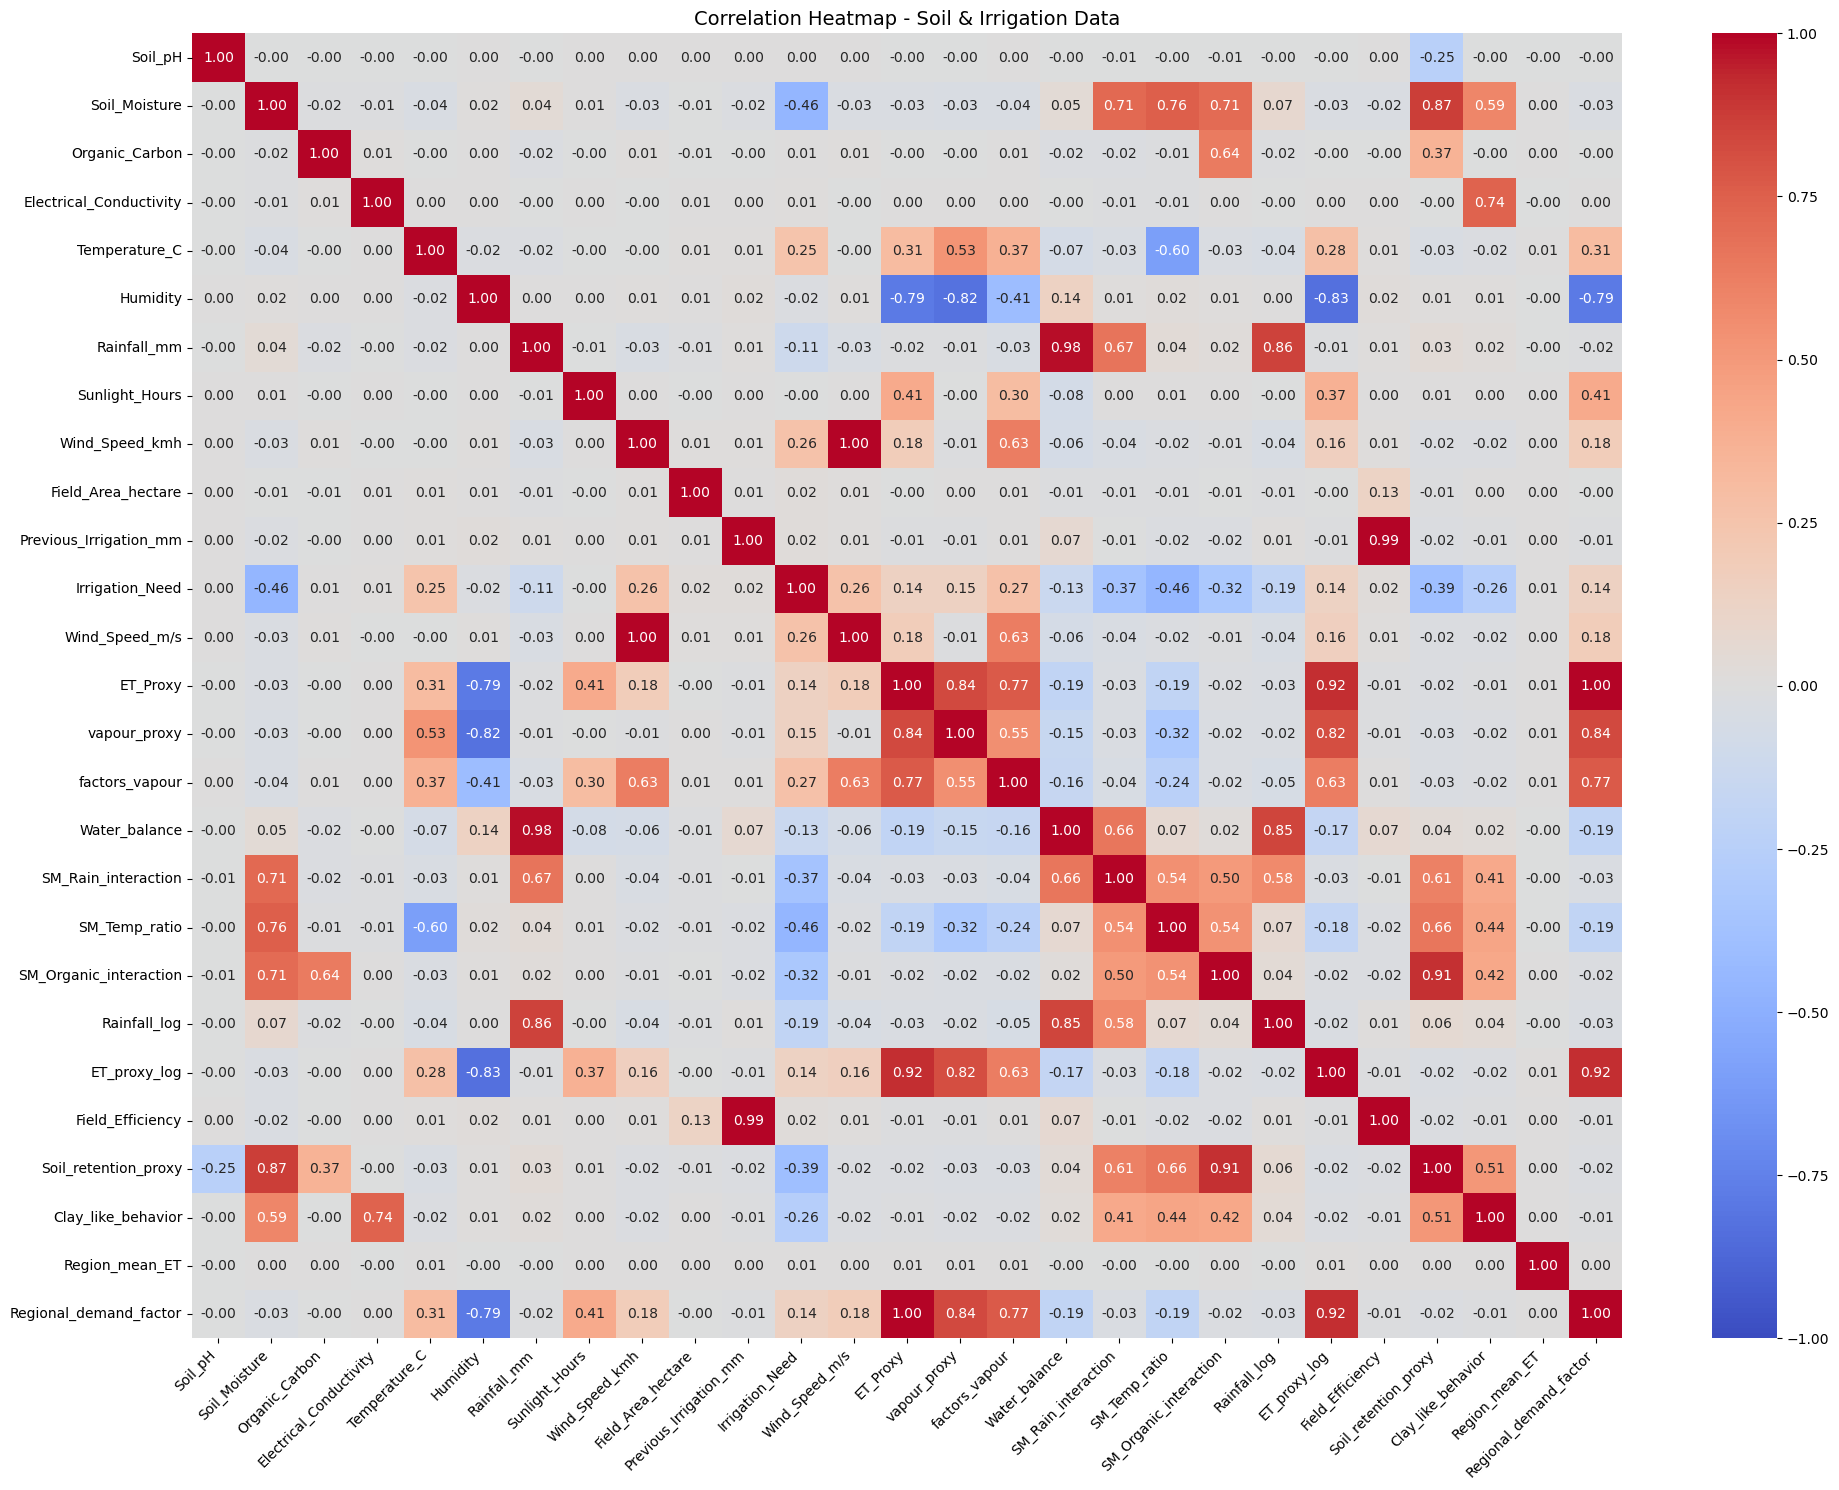

In [40]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])


corr = numeric_df.corr()


plt.figure(figsize=(20, 15))   
sns.heatmap(corr, 
            annot=True,       
            cmap='coolwarm',    
            vmin=-1, 
            vmax=1,
            fmt='.2f')         

plt.title('Correlation Heatmap - Soil & Irrigation Data', fontsize=14)
plt.xticks(rotation=45, ha='right')   
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
sns.lineplot(x='Soil_Type',y='Soil_Moisture',data=df)



In [ ]:
sns.histplot(df["ET_Proxy"],kde=True)

In [ ]:
sns.histplot(df["ET_proxy_log"],kde=True)

# Train Test Split

In [41]:
x= df.drop(["Irrigation_Need"],axis=1)
y=df["Irrigation_Need"]
y = to_categorical(y)
x_train ,x_test ,y_train ,y_test =train_test_split(x,y,train_size=0.8,random_state=42)

# Data Preprocessing

In [42]:
cat_cols = list(x_train.select_dtypes(include=["object"]).columns)
encoder = OrdinalEncoder()
x_train[cat_cols] = encoder.fit_transform(x_train[cat_cols])
x_test[cat_cols] = encoder.transform(x_test[cat_cols])

# scale Data

In [43]:
scaler = StandardScaler()
x_train =scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Data Modeling

In [44]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='tanh' ),
    Dropout(0.2),
    Dense(32, activation='tanh'),
    Dropout(.1),
    Dense(3, activation='softmax')
])

model.summary()

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,915 (58.26 KB)

 Trainable params: 14,915 (58.26 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss = 'categorical_crossentropy', metrics = ['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5)

model.fit(x_train, y_train, epochs=150,
         validation_split=0.1, batch_size=360, 
          callbacks=[early_stopping])

Epoch 1/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7103 - loss: 0.6360 - val_accuracy: 0.7727 - val_loss: 0.4826
Epoch 2/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7836 - loss: 0.4754 - val_accuracy: 0.8664 - val_loss: 0.3229
Epoch 3/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8577 - loss: 0.3399 - val_accuracy: 0.9065 - val_loss: 0.2409
Epoch 4/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8803 - loss: 0.2950 - val_accuracy: 0.9147 - val_loss: 0.2222
Epoch 5/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8909 - loss: 0.2713 - val_accuracy: 0.9210 - val_loss: 0.2076
Epoch 6/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8988 - loss: 0.2523 - val_accuracy: 0.9285 - val_loss: 0.1899
Epoch 7/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9085 - loss: 0.2305 - val_accuracy: 0.9366 - val_loss: 0.1724
Epoch 8/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9173 - loss: 0

In [46]:
model.evaluate(x_test,y_test)

3938/3938 ━━━━━━━━━━━━━━━━━━━━ 3s 799us/step - accuracy: 0.9841 - loss: 0.0645


[0.06448416411876678, 0.9840555787086487]

In [47]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(
        units=hp.Int('units_1', min_value=64, max_value=256, step=64),
        activation='relu',
        input_shape=(x_train.shape[1],)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)))
    
    model.add(Dense(
        units=hp.Int('units_2', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_2', 0.2, 0.5, step=0.1)))
    
    model.add(Dense(
        units=hp.Int('units_3', min_value=16, max_value=64, step=16),
        activation='relu'
    ))
    model.add(Dense(3, activation='softmax'))
    
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4, 1e-4])
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='irrigation_dnn'
)

tuner.search(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=30,
    batch_size=256,
    verbose=1
)

best_model = tuner.get_best_models(num_models=1)[0]

best_hp = tuner.get_best_hyperparameters(1)[0]

print("\n Best Hyperparameters:")
print(best_hp.values)

loss, acc = best_model.evaluate(x_test, y_test)
print(f"\n Best Tuned Accuracy: {acc:.4f}")

Trial 10 Complete [00h 03m 53s]
val_accuracy: 0.9809841513633728

Best val_accuracy So Far: 0.9832698702812195
Total elapsed time: 00h 38m 09s


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



 Best Hyperparameters:
{'units_1': 128, 'dropout_1': 0.4, 'units_2': 96, 'dropout_2': 0.2, 'units_3': 48, 'learning_rate': 0.0005}
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9833 - loss: 0.0649

 Best Tuned Accuracy: 0.9833


In [48]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df['Irrigation_Need']),
    y=df['Irrigation_Need']
)

class_weights_dict = dict(enumerate(weights))

model.fit(x_train, y_train, 
          epochs=150, 
          batch_size=360,
          class_weight=class_weights_dict, 
          validation_split=0.1,
          callbacks=[early_stopping])
model.evaluate(x_test,y_test)

Epoch 1/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9745 - loss: 0.1173 - val_accuracy: 0.9804 - val_loss: 0.0792
Epoch 2/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9740 - loss: 0.1140 - val_accuracy: 0.9798 - val_loss: 0.0811
Epoch 3/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9739 - loss: 0.1141 - val_accuracy: 0.9807 - val_loss: 0.0782
Epoch 4/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9742 - loss: 0.1140 - val_accuracy: 0.9792 - val_loss: 0.0849
Epoch 5/150
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9742 - loss: 0.1125 - val_accuracy: 0.9806 - val_loss: 0.0800
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9813 - loss: 0.0783


[0.0782642513513565, 0.981253981590271]

In [49]:
y_train_labels = np.argmax(y_train, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_model.fit(x_train, y_train_labels)
xgb_preds = xgb_model.predict(x_test)
xgb_acc = accuracy_score(y_test_labels, xgb_preds)

print("Training LightGBM...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
lgb_model.fit(x_train, y_train_labels)
lgb_preds = lgb_model.predict(x_test)
lgb_acc = accuracy_score(y_test_labels, lgb_preds)
 

print("\n" + "="*30)
print("Final Comparison (Accuracy):")
print(f"Deep Learning Model: {0.9831:.4f}")
print(f"XGBoost Model:       {xgb_acc:.4f}")
print(f"LightGBM Model:      {lgb_acc:.4f}")
print("="*30)


print("\nXGBoost Detailed Report:")
print(classification_report(y_test_labels, xgb_preds, target_names=["Low", "Medium", "High"]))

Training XGBoost...


C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:200: UserWarning: [13:40:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training LightGBM...


c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^


Final Comparison (Accuracy):
Deep Learning Model: 0.9831
XGBoost Model:       0.9848
LightGBM Model:      0.9846

XGBoost Detailed Report:
              precision    recall  f1-score   support

         Low       0.99      1.00      0.99     73737
      Medium       0.98      0.98      0.98     48014
        High       0.97      0.91      0.94      4249

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



## Saving Model

In [50]:
import pickle

with open("encoder.pkl" ,"wb") as f:
    pickle.dumps(encoder)

with open("scaler.pkl" ,"wb") as f:
    pickle.dumps(scaler)

In [51]:
model.save("model.h5")

# Data Preprocessing of test data

In [52]:
df_test[cat_cols] = encoder.transform(df_test[cat_cols])

# scale Data

In [53]:
df_test=scaler.transform(df_test)

## predict test

In [54]:
y_pred=model.predict(df_test)

8438/8438 ━━━━━━━━━━━━━━━━━━━━ 8s 964us/step


# submit

In [55]:
reverse= {0:"Low", 1:"Medium", 2:"High"}

preds = []
for pred in y_pred:
    arg = np.argmax(pred)
    output = reverse[arg]

    preds.append(output)

In [56]:
sub['Irrigation_Need'] = preds

In [57]:
sub.to_csv("sub1.csv", index=False)